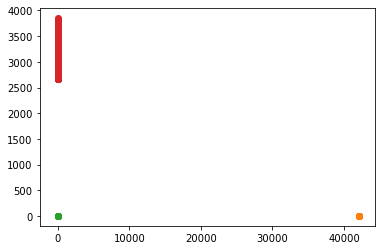

In [2]:
import pandas as pd
import statsmodels.tsa.stattools as ts
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pathname='/Users/aya/Local Documents/NYU/Dissertation/data/BIOWIN_database/1_Datasets/Monthly/normal-op_28days-1hr_alldata.csv'

raw_csv = pd.read_csv(pathname)

plt.scatter(raw_csv["Time (days)"], raw_csv["AERZ1 x2 (75) Gas - Dissolved oxygen"])

plt.scatter(raw_csv["Time (days)"], raw_csv["ML Recycle N - Ammonia"])

m2=raw_csv["ML Recycle N - Ammonia"].rolling(window=24).mean()
N = len(m2)
x1 = np.linspace(0, 29, N, endpoint=True)
plt.scatter(y=m2, x=x1)


m1=raw_csv["AERZ1 x2 (75) COD - Total"].rolling(window=24).mean()
N = len(m1)
x1 = np.linspace(0, 29, N, endpoint=True)
plt.scatter(y=m1, x=x1)


In [ ]:
import pandas as pd
import statsmodels.tsa.stattools as ts
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

pathname='/Users/aya/Local Documents/NYU/Dissertation/data/BIOWIN_database/1_Datasets/Monthly/normal-op_28days-1hr_alldata.csv'

in_csv = pd.read_csv(pathname)

#len(in_csv.columns)

#or i in in_csv.columns:
#    print(i)

#in_csv['rllmean5!Final Effluent COD - Total']=in_csv["Final Effluent COD - Total"].rolling(window=5).mean()

#in_csv['rllmean5!Final Effluent COD - Total'].fillna(0, inplace = True)

def acf_batch_plotter(input_df, save):

    for i in input_df:
        cn = i
        Y = input_df[cn]

        plot_acf(Y, lags = 100)
        plt.suptitle(cn)

        if save is not False:
            plt.savefig(plot_filepath)
            plt.show()
        else:
            plt.show()

    return

acf_batch_plotter(in_csv, save = False)

def pacf_batch_plotter(input_df, save):

    for i in input_df.columns:
        cn = i
        Y = input_df[cn]

        plot_pacf(Y, lags = 300)
        plt.suptitle(cn)

        if save is not False:
            plt.savefig(plot_filepath)
            plt.show()
        else:
            plt.show()

    return

pacf_batch_plotter(in_csv, save = False)


No. of nan values: 1
Test Statistic         -7.907201e+00
p-value                 4.036843e-12
Lags Used               5.000000e+00
Observations Used       6.660000e+02
Critical Value (1%)    -3.440207e+00
Critical Value (5%)    -2.865889e+00
Critical Value (10%)   -2.569086e+00
dtype: float64


/Users/aya/miniconda3/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:1434: RuntimeWarning: invalid value encountered in sqrt
  return rho, np.sqrt(sigmasq)
/Users/aya/miniconda3/lib/python3.7/site-packages/pandas/plotting/_matplotlib/misc.py:409: UserWarning: Requested projection is different from current axis projection, creating new axis with requested projection.
  ax = plt.gca(xlim=(1, n), ylim=(-1.0, 1.0))


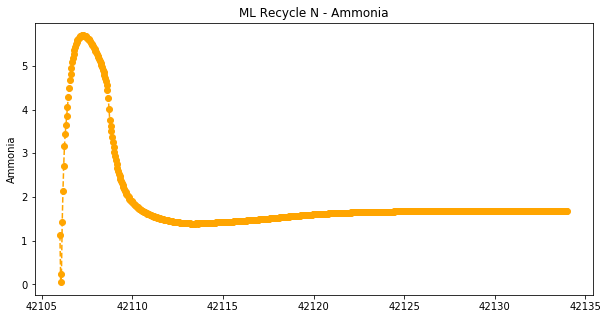

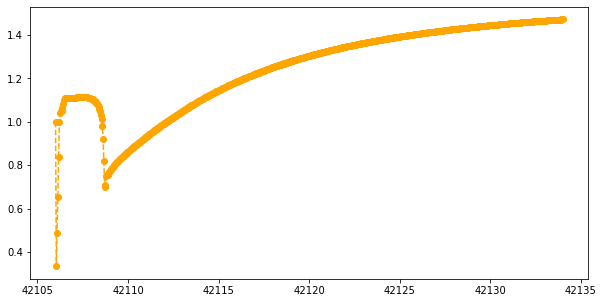

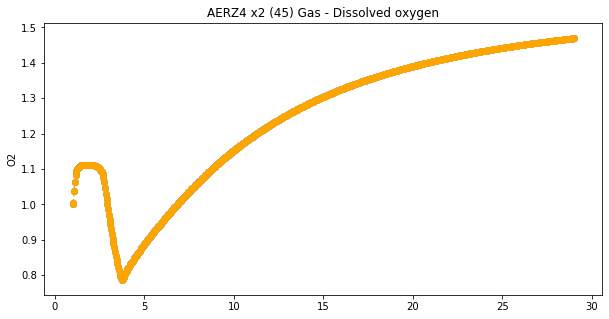

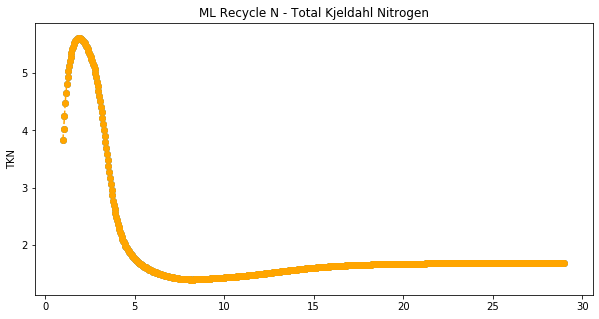

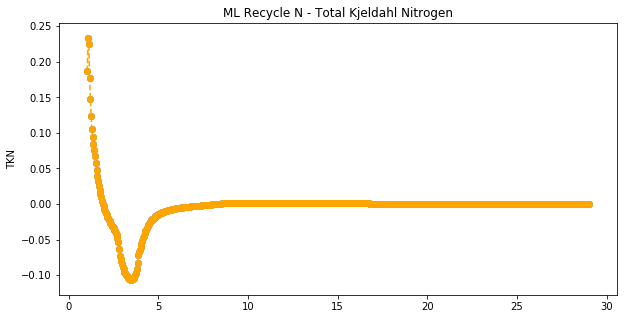

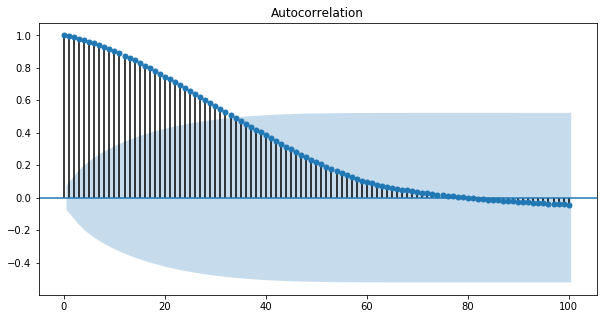

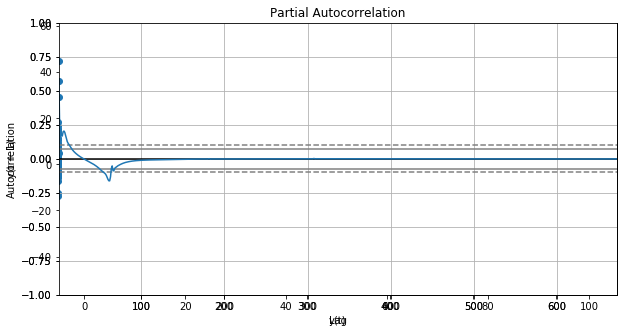

In [5]:
import pandas as pd
import statsmodels.tsa.stattools as ts
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf


pathname='/Users/aya/Local Documents/NYU/Dissertation/data/BIOWIN_database/1_Datasets/Monthly/normal-op_28days-1hr_alldata.csv'

raw_csv = pd.read_csv(pathname)

# for i in raw_csv.columns:
#     print(i)

X = raw_csv["Time (days)"]
y = raw_csv["ML Recycle N - Ammonia"]

fig, ax1 = plt.subplots()

ax1.plot(X, y, marker = 'o', color = 'orange', linestyle = '--')

ax1.set_ylabel('Ammonia')
ax1.set_title('ML Recycle N - Ammonia')

fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 10
fig_size[1] = 5
plt.rcParams["figure.figsize"] = fig_size

X = raw_csv["Time (days)"]
y = raw_csv["AERZ4 x2 (45) Gas - Dissolved oxygen"]

fig, ax1 = plt.subplots()

ax1.plot(X, y, marker = 'o', color = 'orange', linestyle = '--')


m2=raw_csv["AERZ4 x2 (45) Gas - Dissolved oxygen"].rolling(window=24).mean()
N = len(m2)
x1 = np.linspace(0, 29, N, endpoint=True)

fig, ax1 = plt.subplots()

ax1.plot(x1, m2, marker = 'o', color = 'orange', linestyle = '--')

ax1.set_ylabel('O2')
ax1.set_title('AERZ4 x2 (45) Gas - Dissolved oxygen')
plt.scatter(y=m2, x=x1)


m1=raw_csv["ML Recycle N - Ammonia"].rolling(window=24).mean()
N = len(m1)
x1 = np.linspace(0, 29, N, endpoint=True)

fig, ax1 = plt.subplots()

ax1.plot(x1, m1, marker = 'o', color = 'orange', linestyle = '--')

ax1.set_ylabel('TKN')
ax1.set_title('ML Recycle N - Total Kjeldahl Nitrogen')
plt.scatter(y=m1, x=x1)

raw_csv['first_diff!ML Recycle N - Ammonia']=raw_csv['ML Recycle N - Ammonia'].diff()

m1=raw_csv["first_diff!ML Recycle N - Ammonia"].rolling(window=24).mean()
N = len(m1)
x1 = np.linspace(0, 29, N, endpoint=True)

fig, ax1 = plt.subplots()

ax1.plot(x1, m1, marker = 'o', color = 'orange', linestyle = '--')

ax1.set_ylabel('TKN')
ax1.set_title('ML Recycle N - Total Kjeldahl Nitrogen')
plt.scatter(y=m1, x=x1)

print("No. of nan values:", raw_csv['first_diff!ML Recycle N - Ammonia'].isnull().sum())

df_test=ts.adfuller(raw_csv['first_diff!ML Recycle N - Ammonia'][1:],autolag='AIC')
df_results=pd.Series(df_test[0:4],index=['Test Statistic','p-value','Lags Used','Observations Used'])
for key,value in df_test[4].items():
    df_results['Critical Value (%s)'%key] = value
print(df_results)

plot_acf(raw_csv["ML Recycle N - Ammonia"],lags=100)

plot_pacf(raw_csv["ML Recycle N - Ammonia"],lags=100, use_vlines=True)
pd.plotting.autocorrelation_plot(raw_csv["ML Recycle N - Ammonia"])
pd.plotting.autocorrelation_plot(raw_csv["first_diff!ML Recycle N - Ammonia"][1:])
pd.plotting.lag_plot(raw_csv["ML Recycle N - Ammonia"], lag=1)
pd.plotting.lag_plot(raw_csv["first_diff!ML Recycle N - Ammonia"], lag=1)
